<a href="https://colab.research.google.com/github/AnhTran181105/Data-mining/blob/main/Data_mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================================
# ENN EXPERIMENT ON WAVEFORM-NOISE DATASET
# =====================================================

# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.under_sampling import EditedNearestNeighbours


# =====================================================
# 2. LOAD DATASET
# =====================================================

file_path = 'waveform-+noise.data'

# Correctly read the data as comma-separated values
# The file contains 40 features and 1 target variable, all numeric.
# Using header=None as there are no explicit headers.
# Pandas should infer the comma delimiter, or we can explicitly set sep=','
df = pd.read_csv(file_path, header=None)

print("========== DATASET HEAD ==========")
print(df.head())
print()


# =====================================================
# 3. CONVERT TO BINARY CLASSIFICATION (NOT NEEDED FOR THIS DATASET)
#    The target is already in the last column and appears to be multi-class.
# =====================================================


# =====================================================
# 4. DEFINE FEATURES AND LABELS
# =====================================================

X = df.iloc[:, :-1]  # All columns except the last one as features
y = df.iloc[:, -1]   # The last column as the target variable

print("========== CLASS DISTRIBUTION =========")
print(y.value_counts().sort_index()) # Print sorted class distribution
print()


# =====================================================
# 5. TRAIN / TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("========== TRAIN / TEST SIZE ==========")
print("Train Size:", X_train.shape)
print("Test Size :", X_test.shape)
print()


# =====================================================
# 6. STANDARDIZATION
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# =====================================================
# 7. BASELINE MODEL (WITHOUT ENN)
# =====================================================

print("========================================")
print("BASELINE MODEL (WITHOUT ENN)")
print("========================================")

k_neighbors_baseline = 5 # Changed n_neighbors to a variable
knn_baseline = KNeighborsClassifier(n_neighbors=k_neighbors_baseline)

knn_baseline.fit(X_train_scaled, y_train)

y_pred_baseline = knn_baseline.predict(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

baseline_precision = precision_score(
    y_test,
    y_pred_baseline,
    average='weighted' # Adjusted for multi-class
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline,
    average='weighted' # Adjusted for multi-class
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    average='weighted' # Adjusted for multi-class
)

print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-score : {baseline_f1:.4f}")
print()

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_baseline))
print()

print("Classification Report")
print(classification_report(y_test, y_pred_baseline))
print()


# =====================================================
# 8. ENN EXPERIMENTS
# =====================================================

enn_values = [3, 5, 7]
k_neighbors_enn = 5 # Setting n_neighbors for KNN after ENN

for k in enn_values:

    print("========================================")
    print(f"ENN EXPERIMENT - k (for ENN) = {k}")
    print("========================================")

    # =================================================
    # APPLY ENN ONLY ON TRAIN SET
    # =================================================

    enn = EditedNearestNeighbours(
        n_neighbors=k
    )

    X_train_enn, y_train_enn = enn.fit_resample(
        X_train_scaled,
        y_train
    )

    # =================================================
    # SAMPLE ANALYSIS
    # =================================================

    before_samples = len(y_train)

    after_samples = len(y_train_enn)

    removed_samples = before_samples - after_samples

    print("========== SAMPLE ANALYSIS ==========")

    print("Before ENN:", before_samples)

    print("After ENN :", after_samples)

    print("Removed   :", removed_samples)

    print()

    # =================================================
    # CLASS ANALYSIS
    # =================================================

    original_class = pd.Series(y_train).value_counts().sort_index()
    enn_class = pd.Series(y_train_enn).value_counts().sort_index()

    print("========== REMOVED SAMPLES BY CLASS ==========")
    for class_label in original_class.index:
        removed_count = original_class.get(class_label, 0) - enn_class.get(class_label, 0)
        print(f"Removed Class {class_label}: {removed_count}")
    print()

    # =================================================
    # TRAIN KNN AFTER ENN
# =================================================

    knn_enn = KNeighborsClassifier(
        n_neighbors=k_neighbors_enn
    )

    knn_enn.fit(
        X_train_enn,
        y_train_enn
    )

    y_pred_enn = knn_enn.predict(
        X_test_scaled
    )

    # =================================================
    # EVALUATION METRICS
    # =================================================

    accuracy = accuracy_score(
        y_test,
        y_pred_enn
    )

    precision = precision_score(
        y_test,
        y_pred_enn,
        average='weighted' # Adjusted for multi-class
    )

    recall = recall_score(
        y_test,
        y_pred_enn,
        average='weighted' # Adjusted for multi-class
    )

    f1 = f1_score(
        y_test,
        y_pred_enn,
        average='weighted' # Adjusted for multi-class
    )

    print("========== PERFORMANCE ==========")

    print(f"Accuracy : {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1-score : {f1:.4f}")

    print()

    print("========== CONFUSION MATRIX ==========")

    print(confusion_matrix(
        y_test,
        y_pred_enn
    ))

    print()

    print("========== CLASSIFICATION REPORT ==========")

    print(classification_report(
        y_test,
        y_pred_enn
    ))

    print()


# =====================================================
# 9. FINISH
# =====================================================

print("========================================")
print("EXPERIMENT FINISHED")
print("========================================")

========== DATASET HEAD ==========
     0     1     2     3     4     5     6     7     8     9   ...    31  \
0 -0.23 -1.21  1.20  1.23 -0.10  0.12  2.49  1.19  1.34  0.58  ... -0.86   
1  0.38  0.38 -0.31 -0.09  1.52  1.35  1.49  3.81  2.33  1.34  ...  1.28   
2 -0.69  1.00  1.08  1.48  2.44  3.39  3.09  4.08  5.48  3.61  ...  0.29   
3  0.40  0.68  0.27  1.39  1.03 -0.32 -1.23 -0.50  0.11  0.87  ...  0.43   
4 -0.81  1.59 -0.69  1.16  4.22  4.98  4.52  2.54  5.60  4.66  ...  0.62   

     32    33    34    35    36    37    38    39  40  
0 -0.70  0.51  0.34 -0.13 -0.87  0.56 -0.53  0.29   2  
1  1.40  0.00 -0.18  0.71  0.04  0.91 -0.79  0.22   0  
2  1.12  0.60  0.28  2.17  0.18 -0.09 -1.33  1.00   1  
3 -0.30 -0.07 -0.99 -0.75  1.11  1.35 -1.63  0.10   0  
4  0.14  1.33 -1.87  1.48 -0.02 -0.58  0.93  0.40   1  

[5 rows x 41 columns]

========== CLASS DISTRIBUTION =========
40
0    1692
1    1653
2    1655
Name: count, dtype: int64

========== TRAIN / TEST SIZE ==========
Train Si

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4471/1954052220.py:15: SyntaxWarning: invalid escape sequence '\s'
  df_waveform = pd.read_csv(file_path, sep='\s+', header=None)


========== DATASET HEAD (inferred separator) ==========
   -0.23  -1.21  1.20  1.23  -0.10  0.12  2.49  1.19  1.34  0.58  ...  -0.86  \
0   0.38   0.38 -0.31 -0.09   1.52  1.35  1.49  3.81  2.33  1.34  ...   1.28   
1  -0.69   1.00  1.08  1.48   2.44  3.39  3.09  4.08  5.48  3.61  ...   0.29   
2   0.40   0.68  0.27  1.39   1.03 -0.32 -1.23 -0.50  0.11  0.87  ...   0.43   
3  -0.81   1.59 -0.69  1.16   4.22  4.98  4.52  2.54  5.60  4.66  ...   0.62   
4   0.59   0.77 -0.61  1.00   1.80  2.08  2.16  3.59  4.08  3.63  ...   1.23   

   -0.70  0.51  0.34  -0.13  -0.87  0.56  -0.53  0.29  2  
0   1.40  0.00 -0.18   0.71   0.04  0.91  -0.79  0.22  0  
1   1.12  0.60  0.28   2.17   0.18 -0.09  -1.33  1.00  1  
2  -0.30 -0.07 -0.99  -0.75   1.11  1.35  -1.63  0.10  0  
3   0.14  1.33 -1.87   1.48  -0.02 -0.58   0.93  0.40  1  
4  -0.29 -1.62  0.19  -1.04   0.43 -1.82  -1.14 -0.23  1  

[5 rows x 41 columns]


### 4. Define Features and Labels for `df_waveform`

In [ ]:
X_waveform = df_waveform.iloc[:, :-1]  # All columns except the last one as features
y_waveform = df_waveform.iloc[:, -1]   # The last column as the target variable

print("========== FEATURES HEAD (X_waveform) ==========")
print(X_waveform.head())
print("\n========== LABELS HEAD (y_waveform) ==========")
print(y_waveform.head())
print("\nFeatures shape:", X_waveform.shape)
print("Labels shape:", y_waveform.shape)

========== FEATURES HEAD (X_waveform) ==========
   -0.23  -1.21  1.20  1.23  -0.10  0.12  2.49  1.19  1.34  0.58  ...  -0.63  \
0   0.38   0.38 -0.31 -0.09   1.52  1.35  1.49  3.81  2.33  1.34  ...   0.31   
1  -0.69   1.00  1.08  1.48   2.44  3.39  3.09  4.08  5.48  3.61  ...   0.93   
2   0.40   0.68  0.27  1.39   1.03 -0.32 -1.23 -0.50  0.11  0.87  ...   1.18   
3  -0.81   1.59 -0.69  1.16   4.22  4.98  4.52  2.54  5.60  4.66  ...  -0.07   
4   0.59   0.77 -0.61  1.00   1.80  2.08  2.16  3.59  4.08  3.63  ...  -0.15   

   -0.86  -0.70  0.51  0.34  -0.13  -0.87  0.56  -0.53  0.29  
0   1.28   1.40  0.00 -0.18   0.71   0.04  0.91  -0.79  0.22  
1   0.29   1.12  0.60  0.28   2.17   0.18 -0.09  -1.33  1.00  
2   0.43  -0.30 -0.07 -0.99  -0.75   1.11  1.35  -1.63  0.10  
3   0.62   0.14  1.33 -1.87   1.48  -0.02 -0.58   0.93  0.40  
4   1.23  -0.29 -1.62  0.19  -1.04   0.43 -1.82  -1.14 -0.23  

[5 rows x 40 columns]

========== LABELS HEAD (y_waveform) ==========
0    0
1    1
2    0


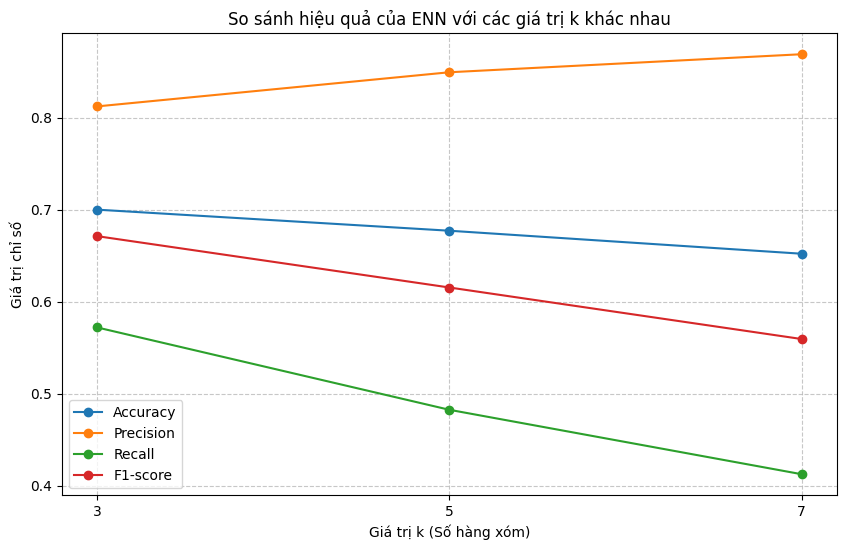

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data collection from the previous experiment results
k_values = [3, 5, 7]
metrics = {
    'Accuracy': [0.7000, 0.6771, 0.6521],
    'Precision': [0.8122, 0.8493, 0.8689],
    'Recall': [0.5720, 0.4825, 0.4125],
    'F1-score': [0.6712, 0.6154, 0.5594]
}

# Plotting
plt.figure(figsize=(10, 6))
for metric_name, values in metrics.items():
    plt.plot(k_values, values, marker='o', label=metric_name)

plt.title('So sánh hiệu quả của ENN với các giá trị k khác nhau')
plt.xlabel('Giá trị k (Số hàng xóm)')
plt.ylabel('Giá trị chỉ số')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
# =====================================================
# ENN EXPERIMENT ON WAVEFORM-NOISE DATASET
# =====================================================

# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.under_sampling import EditedNearestNeighbours


# =====================================================
# 2. LOAD DATASET
# =====================================================

file_path = 'waveform-+noise.data'

# Correctly read the data as comma-separated values
# The file contains 40 features and 1 target variable, all numeric.
# Using header=None as there are no explicit headers.
# Pandas should infer the comma delimiter, or we can explicitly set sep=','
df = pd.read_csv(file_path, header=None)

print("========== DATASET HEAD ==========")
print(df.head())
print()


# =====================================================
# 3. CONVERT TO BINARY CLASSIFICATION (NOT NEEDED FOR THIS DATASET)
#    The target is already in the last column and appears to be multi-class.
# =====================================================


# =====================================================
# 4. DEFINE FEATURES AND LABELS
# =====================================================

X = df.iloc[:, :-1]  # All columns except the last one as features
y = df.iloc[:, -1]   # The last column as the target variable

print("========== CLASS DISTRIBUTION ========")
print(y.value_counts().sort_index()) # Print sorted class distribution
print()


# =====================================================
# 5. TRAIN / TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("========== TRAIN / TEST SIZE ==========")
print("Train Size:", X_train.shape)
print("Test Size :", X_test.shape)
print()


# =====================================================
# 6. STANDARDIZATION
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# =====================================================
# 7. BASELINE MODEL (WITHOUT ENN)
# =====================================================

print("========================================")
print("BASELINE MODEL (WITHOUT ENN)")
print("========================================")

k_neighbors_baseline = 5 # Changed n_neighbors to a variable
knn_baseline = KNeighborsClassifier(n_neighbors=k_neighbors_baseline)

knn_baseline.fit(X_train_scaled, y_train)

y_pred_baseline = knn_baseline.predict(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

baseline_precision = precision_score(
    y_test,
    y_pred_baseline,
    average='weighted' # Adjusted for multi-class
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline,
    average='weighted' # Adjusted for multi-class
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    average='weighted' # Adjusted for multi-class
)

print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-score : {baseline_f1:.4f}")
print()

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_baseline))
print()

print("Classification Report")
print(classification_report(y_test, y_pred_baseline))
print()


# =====================================================
# 8. ENN EXPERIMENTS
# =====================================================

enn_values = [3, 5, 7]
k_neighbors_enn = 5 # Setting n_neighbors for KNN after ENN

for k in enn_values:

    print("========================================")
    print(f"ENN EXPERIMENT - k (for ENN) = {k}")
    print("========================================")

    # =================================================
    # APPLY ENN ONLY ON TRAIN SET
    # =================================================

    enn = EditedNearestNeighbours(
        n_neighbors=k
    )

    X_train_enn, y_train_enn = enn.fit_resample(
        X_train_scaled,
        y_train
    )

    # =================================================
    # SAMPLE ANALYSIS
    # =================================================

    before_samples = len(y_train)

    after_samples = len(y_train_enn)

    removed_samples = before_samples - after_samples

    print("========== SAMPLE ANALYSIS ==========")

    print("Before ENN:", before_samples)

    print("After ENN :", after_samples)

    print("Removed   :", removed_samples)

    print()

    # =================================================
    # CLASS ANALYSIS
    # =================================================

    original_class = pd.Series(y_train).value_counts().sort_index()
    enn_class = pd.Series(y_train_enn).value_counts().sort_index()

    print("========== REMOVED SAMPLES BY CLASS ==========")
    for class_label in original_class.index:
        removed_count = original_class.get(class_label, 0) - enn_class.get(class_label, 0)
        print(f"Removed Class {class_label}: {removed_count}")
    print()

    # =================================================
    # TRAIN KNN AFTER ENN
# =================================================

    knn_enn = KNeighborsClassifier(
        n_neighbors=k_neighbors_enn
    )

    knn_enn.fit(
        X_train_enn,
        y_train_enn
    )

    y_pred_enn = knn_enn.predict(
        X_test_scaled
    )

    # =================================================
    # EVALUATION METRICS
    # =================================================

    accuracy = accuracy_score(
        y_test,
        y_pred_enn
    )

    precision = precision_score(
        y_test,
        y_pred_enn,
        average='weighted' # Adjusted for multi-class
    )

    recall = recall_score(
        y_test,
        y_pred_enn,
        average='weighted' # Adjusted for multi-class
    )

    f1 = f1_score(
        y_test,
        y_pred_enn,
        average='weighted' # Adjusted for multi-class
    )

    print("========== PERFORMANCE ==========")

    print(f"Accuracy : {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1-score : {f1:.4f}")

    print()

    print("========== CONFUSION MATRIX ==========")

    print(confusion_matrix(
        y_test,
        y_pred_enn
    ))

    print()

    print("========== CLASSIFICATION REPORT ==========")

    print(classification_report(
        y_test,
        y_pred_enn
    ))

    print()


# =====================================================
# 9. FINISH
# =====================================================

print("========================================")
print("EXPERIMENT FINISHED")
print("========================================")

========== DATASET HEAD ==========
     0     1     2     3     4     5     6     7     8     9   ...    31  \
0 -0.23 -1.21  1.20  1.23 -0.10  0.12  2.49  1.19  1.34  0.58  ... -0.86   
1  0.38  0.38 -0.31 -0.09  1.52  1.35  1.49  3.81  2.33  1.34  ...  1.28   
2 -0.69  1.00  1.08  1.48  2.44  3.39  3.09  4.08  5.48  3.61  ...  0.29   
3  0.40  0.68  0.27  1.39  1.03 -0.32 -1.23 -0.50  0.11  0.87  ...  0.43   
4 -0.81  1.59 -0.69  1.16  4.22  4.98  4.52  2.54  5.60  4.66  ...  0.62   

     32    33    34    35    36    37    38    39  40  
0 -0.70  0.51  0.34 -0.13 -0.87  0.56 -0.53  0.29   2  
1  1.40  0.00 -0.18  0.71  0.04  0.91 -0.79  0.22   0  
2  1.12  0.60  0.28  2.17  0.18 -0.09 -1.33  1.00   1  
3 -0.30 -0.07 -0.99 -0.75  1.11  1.35 -1.63  0.10   0  
4  0.14  1.33 -1.87  1.48 -0.02 -0.58  0.93  0.40   1  

[5 rows x 41 columns]

========== CLASS DISTRIBUTION ========
40
0    1692
1    1653
2    1655
Name: count, dtype: int64

========== TRAIN / TEST SIZE ==========
Train Siz

**Code sau khi sửa theo phần feedback**

In [1]:
# =====================================================
# ENN EXPERIMENT ON WAVEFORM-NOISE DATASET
# =====================================================
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from imblearn.under_sampling import EditedNearestNeighbours
# =====================================================
# 2. LOAD DATASET
# =====================================================
file_path = "waveform-+noise.data"
df = pd.read_csv(
    file_path,
    header=None
)
print("========== DATASET HEAD ==========")
print(df.head())
print()
# =====================================================
# 3. DEFINE FEATURES AND LABELS
# =====================================================
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
print("========== CLASS DISTRIBUTION ==========")
print(y.value_counts().sort_index())
print()
# =====================================================
# 4. TRAIN / TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)
print("========== TRAIN / TEST SIZE ==========")
print("Train Size:", X_train.shape)
print("Test Size :", X_test.shape)
print()
# =====================================================
# 5. STANDARDIZATION
# =====================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# =====================================================
# 6. BASELINE MODEL (WITHOUT ENN)
# =====================================================
print("========================================")
print("BASELINE MODEL (WITHOUT ENN)")
print("========================================")
knn_baseline = KNeighborsClassifier(
    n_neighbors=5
)
knn_baseline.fit(
    X_train_scaled,
    y_train
)
y_pred_baseline = knn_baseline.predict(
    X_test_scaled
)
baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)
baseline_precision = precision_score(
    y_test,
    y_pred_baseline,
    average="weighted"
)
baseline_recall = recall_score(
    y_test,
    y_pred_baseline,
    average="weighted"
)
baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    average="weighted"
)
baseline_macro_f1 = f1_score(
    y_test,
    y_pred_baseline,
    average="macro"
)
print(f"Accuracy  : {baseline_accuracy:.4f}")
print(f"Precision : {baseline_precision:.4f}")
print(f"Recall    : {baseline_recall:.4f}")
print(f"F1-score  : {baseline_f1:.4f}")
print(f"Macro F1  : {baseline_macro_f1:.4f}")
print()
print("========== CONFUSION MATRIX ==========")
print(confusion_matrix(
    y_test,
    y_pred_baseline
))
print()
print("========== CLASSIFICATION REPORT ==========")
print(classification_report(
    y_test,
    y_pred_baseline
))
print()
# =====================================================
# 7. ENN EXPERIMENTS
# =====================================================
enn_values = [3, 5, 7]
for k in enn_values:
    print("========================================")
    print(f"ENN EXPERIMENT - k = {k}")
    print("========================================")
    # =================================================
    # APPLY ENN ONLY ON TRAIN SET
    # =================================================
    enn = EditedNearestNeighbours(
        n_neighbors=k,
        sampling_strategy="all",
        kind_sel="all"
    )
    X_train_enn, y_train_enn = enn.fit_resample(
        X_train_scaled,
        y_train
    )
    # =================================================
    # SAMPLE ANALYSIS
    # =================================================
    before_samples = len(y_train)
    after_samples = len(y_train_enn)
    removed_samples = before_samples - after_samples
    print("========== SAMPLE ANALYSIS ==========")
    print("Before ENN :", before_samples)
    print("After ENN  :", after_samples)
    print("Removed    :", removed_samples)
    print()
    # =================================================
    # CLASS ANALYSIS
    # =================================================
    original_class = pd.Series(
        y_train
    ).value_counts().sort_index()
    enn_class = pd.Series(
        y_train_enn
    ).value_counts().sort_index()
    print("========== REMOVED SAMPLES BY CLASS ==========")
    for class_label in sorted(original_class.index):
        removed_count = (
            original_class[class_label]
            - enn_class.get(class_label, 0)
        )
        print(
            f"Removed Class {class_label}: "
            f"{removed_count}"
        )
    print()
    # =================================================
    # TRAIN KNN ON CLEANED DATA
    # =================================================
    knn_enn = KNeighborsClassifier(
        n_neighbors=5
    )
    knn_enn.fit(
        X_train_enn,
        y_train_enn
    )
    y_pred_enn = knn_enn.predict(
        X_test_scaled
    )
    # =================================================
    # EVALUATION
    # =================================================
    accuracy = accuracy_score(
        y_test,
        y_pred_enn
    )
    precision = precision_score(
        y_test,
        y_pred_enn,
        average="weighted"
    )
    recall = recall_score(
        y_test,
        y_pred_enn,
        average="weighted"
    )
    f1 = f1_score(
        y_test,
        y_pred_enn,
        average="weighted"
    )
    macro_f1 = f1_score(
        y_test,
        y_pred_enn,
        average="macro"
    )
    print("========== PERFORMANCE ==========")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")
    print()
    # =================================================
    # CONFUSION MATRIX
    # =================================================
    print("========== CONFUSION MATRIX ==========")
    print(confusion_matrix(
        y_test,
        y_pred_enn
    ))
    print()
    # =================================================
    # CLASSIFICATION REPORT
    # =================================================
    print("========== CLASSIFICATION REPORT ==========")
    print(classification_report(
        y_test,
        y_pred_enn
    ))
    print()

# =====================================================
# 8. FINISH
# =====================================================
print("========================================")
print("EXPERIMENT FINISHED")
print("========================================")

========== DATASET HEAD ==========
     0     1     2     3     4     5     6     7     8     9   ...    31  \
0 -0.23 -1.21  1.20  1.23 -0.10  0.12  2.49  1.19  1.34  0.58  ... -0.86   
1  0.38  0.38 -0.31 -0.09  1.52  1.35  1.49  3.81  2.33  1.34  ...  1.28   
2 -0.69  1.00  1.08  1.48  2.44  3.39  3.09  4.08  5.48  3.61  ...  0.29   
3  0.40  0.68  0.27  1.39  1.03 -0.32 -1.23 -0.50  0.11  0.87  ...  0.43   
4 -0.81  1.59 -0.69  1.16  4.22  4.98  4.52  2.54  5.60  4.66  ...  0.62   

     32    33    34    35    36    37    38    39  40  
0 -0.70  0.51  0.34 -0.13 -0.87  0.56 -0.53  0.29   2  
1  1.40  0.00 -0.18  0.71  0.04  0.91 -0.79  0.22   0  
2  1.12  0.60  0.28  2.17  0.18 -0.09 -1.33  1.00   1  
3 -0.30 -0.07 -0.99 -0.75  1.11  1.35 -1.63  0.10   0  
4  0.14  1.33 -1.87  1.48 -0.02 -0.58  0.93  0.40   1  

[5 rows x 41 columns]

========== CLASS DISTRIBUTION ==========
40
0    1692
1    1653
2    1655
Name: count, dtype: int64

========== TRAIN / TEST SIZE ==========
Train S